### IMPORTING NECESSARY LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.linear_model as lm

### Reading files

In [2]:
oecd_bli = pd.read_csv("./data-main/lifesat/oecd_bli.csv")
gdp_per_capita = pd.read_csv("./data-main/lifesat/gdp_per_capita.csv")

In [3]:
d = gdp_per_capita.groupby('Entity')['GDP per capita, PPP (constant 2017 international $)'].mean().to_dict()


In [4]:
e = oecd_bli.groupby('Country')['Value'].mean().to_dict()

### Matching existing Countries

In [5]:
x = np.array([])
y = np.array([])
for c in d.keys():
    if c in e.keys():
        x = np.append(x, d[c])
        y = np.append(y, e[c])

### Reshaping the data
necessary for using Linear Regression Model. should be 2D. Scikit-Learn NEEDS THIS.


In [6]:
X = x.reshape(-1, 1)
Y = y.reshape(-1, 1)
model = lm.LinearRegression()
model.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Model parameters

In [7]:
print(f"Intercept (θ₀): {model.intercept_[0]:.4f}")
print(f"Slope (θ₁): {model.coef_[0][0]:.6f}")
print(f"Formula: Life Satisfaction = {model.intercept_[0]:.4f} + ({model.coef_[0][0]:.6f} × GDP)")
# Model accuracy (R² Score)
r2_score = model.score(X, Y)
print(f"R² Score: {r2_score:.4f}")

Intercept (θ₀): -977.7476
Slope (θ₁): 0.147721
Formula: Life Satisfaction = -977.7476 + (0.147721 × GDP)
R² Score: 0.4794


### Plotting the Data

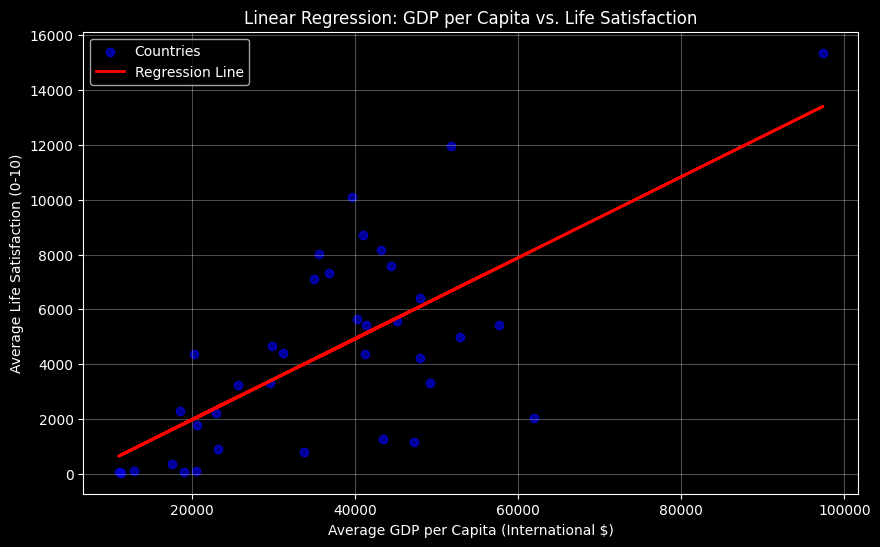

In [8]:
# Plot the data and the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', alpha=0.6, label='Countries')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Average GDP per Capita (International $)')
plt.ylabel('Average Life Satisfaction (0-10)')
plt.title('Linear Regression: GDP per Capita vs. Life Satisfaction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()